In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('AB_NYC_2019.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:

# Fill missing reviews_per_month with 0
df['reviews_per_month'].fillna(0, inplace=True)

# Drop rows with missing last_review
df.dropna(subset=['last_review'], inplace=True)

# Remove crazy high prices (over $1000)
df = df[df['price'] <= 1000]

# Check that missing values are fixed
print("MISSING VALUES AFTER CLEANING:")
print(df.isnull().sum())
print("\nDATA IS NOW CLEAN!")

MISSING VALUES AFTER CLEANING:
id                                 0
name                               6
host_id                            0
host_name                         16
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

DATA IS NOW CLEAN!


C:\Users\HP\AppData\Local\Temp\ipykernel_10504\2182142278.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)


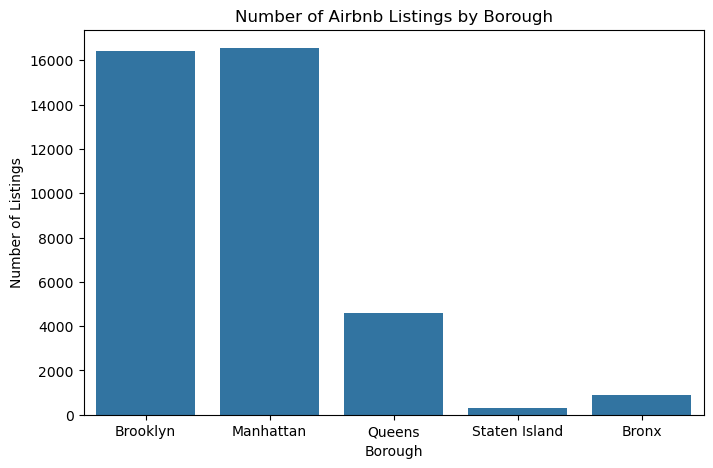

INSIGHT: Manhattan and Brooklyn have the most Airbnbs.
Staten Island has the fewest.


In [8]:

# This shows how many Airbnbs in each borough

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood_group')
plt.title('Number of Airbnb Listings by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Listings')
plt.show()

# INSIGHT 1:
print("INSIGHT: Manhattan and Brooklyn have the most Airbnbs.")
print("Staten Island has the fewest.")

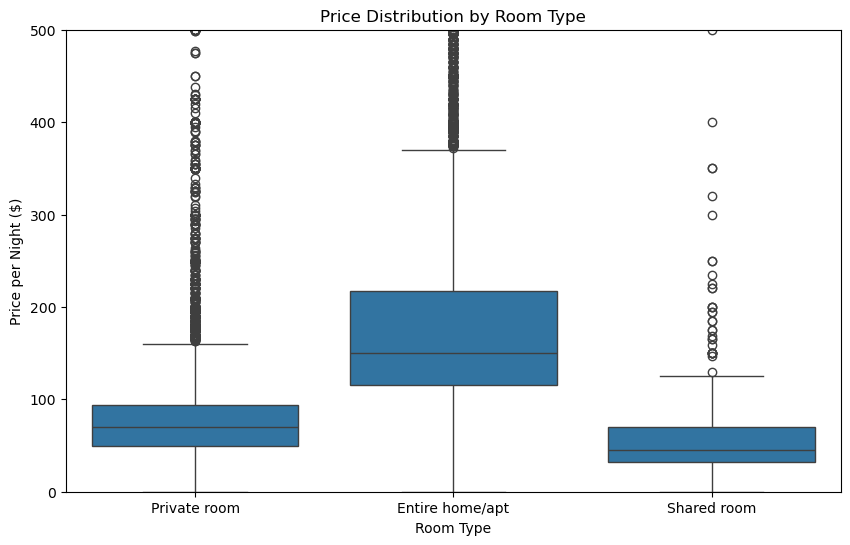

INSIGHT: Entire homes/apartments cost the most money.
Shared rooms are the cheapest option.


In [9]:

# This shows price distribution by room type

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price per Night ($)')
plt.ylim(0, 500)  # This makes the chart easier to read
plt.show()

# INSIGHT 2:
print("INSIGHT: Entire homes/apartments cost the most money.")
print("Shared rooms are the cheapest option.")

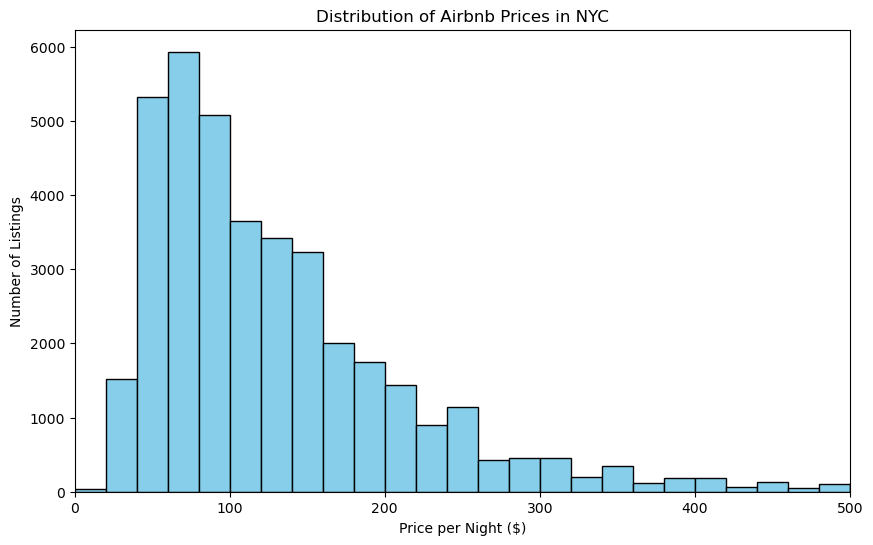

INSIGHT: Most Airbnbs cost between $50 and $150 per night.
Very few listings cost over $300 per night.


In [10]:

# This shows how prices are distributed

plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Airbnb Prices in NYC')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Listings')
plt.xlim(0, 500)
plt.show()

# INSIGHT 3:
print("INSIGHT: Most Airbnbs cost between $50 and $150 per night.")
print("Very few listings cost over $300 per night.")